In [1]:
import pandas as pd
import numpy as np
import re
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.cm as cm

# =========================================================
# 0) Input
# =========================================================
file_path = "data_temp.xlsx"     # <- change if needed
sheet_name = "Sheet1"

# =========================================================
# 1) Load + basic cleanup
# =========================================================
df = pd.read_excel(file_path, sheet_name=sheet_name).rename(columns={
    "金属": "Metal",
    "MOF": "MOF",
    "合成方法": "Synthesis",
    "是否在外表面": "Location"
})

df["Location"] = df["Location"].replace({0: "No", 1: "Yes", "0": "No", "1": "Yes", "Yes": "Yes", "No": "No"})
df["Location"] = df["Location"].where(df["Location"].isin(["Yes", "No"]), np.nan)

# =========================================================
# 2) Normalize + bucket synthesis (then merge tiny buckets)
# =========================================================
synthesis_mapping = {
    "SI": "Solution impregnation",
    "CVD": "Chemical vapor deposition",
    "SG": "Solid grinding",
    "solvent-free gas-phase infiltration": "Chemical vapor deposition",
    "DSM": "Double solvent method",
    "Electrodeposition": "Electrodeposition",
    "Incipient wetness impregnation": "Incipient wetness impregnation",
    "One-pot synthesis": "One-pot synthesis",
    "MOCVD": "Chemical vapor deposition",
    "Bottle-around-ship": "Bottle-around-ship",
    "immobilization": "Solution impregnation",
    "In-situ encapsulation": "One-pot synthesis",
    "wetness impregnation": "Incipient wetness impregnation",
}
df["Synthesis_norm"] = df["Synthesis"].replace(synthesis_mapping)

def bucket_synthesis_clear(s):
    if pd.isna(s):
        return np.nan
    s1 = str(s).strip()
    low = s1.lower()

    if re.search(r"(arc\s*plasma|plasma|sputter|pvd|physical\s*vapor|evaporation)", low):
        return "Physical / plasma deposition"
    if re.search(r"(chemical vapor|mocvd|cvd|gas[-\s]*phase|vapor infiltration|vapour infiltration)", low):
        return "Chemical vapor deposition / infiltration"
    if re.search(r"(electrodeposition|electrochemical)", low):
        return "Electrochemical deposition"
    if re.search(r"(solid grinding|grinding|mechanochem|ball milling|milling)", low):
        return "Mechanochemical synthesis"
    if re.search(r"(bottle[-\s]*around[-\s]*ship)", low):
        return "Bottle-around-ship"
    if re.search(r"(one[-\s]*pot|in[-\s]*situ|encapsulat)", low):
        return "One-pot / in-situ encapsulation"
    if re.search(r"(solution impregnation|incipient wetness|double solvent|wetness impregnation|impregnation)", low):
        return "Liquid-phase impregnation"
    return "Others"

df["Synthesis_grouped"] = df["Synthesis_norm"].apply(bucket_synthesis_clear)

# Merge two tiny deposition categories (avoid label overlap)
df["Synthesis_grouped"] = df["Synthesis_grouped"].replace({
    "Physical / plasma deposition": "Physical/electrochemical deposition",
    "Electrochemical deposition": "Physical/electrochemical deposition"
})

# =========================================================
# 3) Normalize MOF names (mapping + strip trailing (Metal))
# =========================================================
mof_mapping = {
    "[Ni(C10H26N6)](ClO4)2": "[Ni(C₁₀H₂₆N₆)](ClO₄)₂",
    "[Ni(cyclam)](ClO4)2": "[Ni(cyclam)](ClO₄)₂",
    "Ni-MOF": "Ni-MOF",
    "MOF-508(Zn)": "MOF-508",
    "Cu(BTC)": "Cu(BTC)",
    "MIL-68(In)": "MIL-68",
    "ZIF-8(Zn)": "ZIF-8",
    "MIL-101(Cr)": "MIL-101",
    "UiO-66-NH2": "UiO-66-NH₂",
    "Zn-MOF": "Zn-MOF",
    "ZIF-67(Co)": "ZIF-67",
    "Zr-fcu-MOF-BDC": "Zr-fcu-MOF-BDC",
    "Zr-fcu-MOF-NDC": "Zr-fcu-MOF-NDC",
    "MIL-125-NH2": "MIL-125-NH₂",
    "Zr-TTFTB-MOF": "Zr-TTFTB-MOF",
    "MIL-53(Al)": "MIL-53",
    "([Cu2-(pzdc)2(bpy)]n(CPL-2)": "([Cu₂-(pzdc)₂(bpy)]ₙ(CPL-2)",
    "ED-MIL-101(Cr)": "MIL-101",
    "MOF-5(Zn)": "MOF-5",
    "CPL-2": "CPL-2",
    "ZIF-8": "ZIF-8",
    "ZIF-90(Zn)": "ZIF-90",
    "[Cd2(L)(H2O)]·0.5H2O": "[Cd₂(L)(H₂O)]·0.5H₂O",
    "ED-MIL-101": "MIL-101",
    "IRMOF-3(Zn)": "IRMOF-3",
    "MIL-101-NH2(Cr)": "MIL-101-NH₂",
    "MIL-100(Fe)": "MIL-100",
    "MIL-125(Ti)": "MIL-125",
    "Cu-MOF": "Cu-MOF",
    "UiO-66": "UiO-66",
    "MIL-125": "MIL-125",
    "MOF-808": "MOF-808",
    "MIL-101(Fe)": "MIL-101(Fe)",
    "MOF-177(Zn)": "MOF-177",
    "[{[Ni(cyclam)]2(mtb)}n]·8nH2O·4nDMF": "[{[Ni(cyclam)]₂(mtb)}ₙ]·8nH₂O·4nDMF",
    "[Zn3(ntb)2(EtOH)2]": "[Zn₃(ntb)₂(EtOH)₂]",
    "MIL-100(Al)": "MIL-100",
    "[Tm(μ2-L)(μ4-L)0.5(H2O)2]·3H2O (Tm-MOF)": "[Tm(μ₂-L)(μ₄-L)0.5(H₂O)₂]·3H₂O (Tm-MOF)",
    "{[Zn(Himdc)(bipy)0.5].DMF}": "{[Zn(Himdc)(bipy)0.5]·DMF}",
    "MIL-101(Al)": "MIL-101",
    "MIL-53-NH2(Al)": "MIL-53-NH₂",
    "MOF1(UiO-67)": "MOF-1(UiO-67)",
    "MIL-88B-NH2 (Fe)": "MIL-88B-NH₂",
    "SO3H-MIL-101(Cr)": "SO₃H-MIL-101",
    "UiO-66-OMe": "UiO-66-OMe",
    "UiO-68": "UiO-68",
    "UiO-68-NH2": "UiO-68-NH₂",
    "Zn(pip)(dpb)(Zn-MOF)": "Zn(pip)(dpb)(Zn-MOF)",
    "PCN-224(Zr)": "PCN-224",
    "ZIF-67(Zn)": "ZIF-67",
    "HKUST-1-R(Cu)": "HKUST-1-R",
    "UiO-66-2OH": "UiO-66-2OH",
    "MIL-101-F3": "MIL-101-F₃",
    "Zr6(μ3-O)4(μ3-OH)4(bpdc)5.94(L1)0.06 (UiO-67-1)":
        "Zr₆(μ₃-O)₄(μ₃-OH)₄(bpdc)5.94(L₁)0.06 (UiO-67-1)",
    "Zr6(μ3-O)4(μ3-OH)4(L2)6·64DMF (UiO-67-2)":
        "Zr₆(μ₃-O)₄(μ₃-OH)₄(L₂)₆·64DMF (UiO-67-2)",
    "UiO-66-NH2(Zr)": "UiO-66-NH₂",
    "DUT-5(Al)": "DUT-5",
    "MOF-525(Zr)": "MOF-525",
    "MOF-74(Co)": "MOF-74",
    "UiO-67": "UiO-67",
    "PCN-777(Zr)": "PCN-777",
    "NU-901(Zr)": "NU-901",
    "Fe-MOf": "Fe-MOF",
    "S-MIL-101(Cr)": "S-MIL-101",
    "La(1,3,5-BTC)·6(H2O)": "La(1,3,5-BTC)·6(H₂O)",
    "MesMOF-1(Tb)": "MesMOF-1",
    "MIL-120(Al)": "MIL-120",
    "MIL-53(Co)": "MIL-53",
}
df["MOF_norm_base"] = df["MOF"].replace(mof_mapping)

# A version: strip only trailing "(Fe)"-style suffix
df["MOF_norm"] = df["MOF_norm_base"].astype(str).str.replace(r"\([A-Z][a-z]?\)$", "", regex=True).str.strip()

# =========================================================
# 4) Keep only single-metal symbols, then merge tiny metals to Others
# =========================================================
df["Metal"] = df["Metal"].astype(str).str.strip()
df = df[df["Metal"].str.match(r"^[A-Z][a-z]?$", na=False)].copy()

METAL_TOPN = 10
metal_counts = df["Metal"].value_counts()
keep_metals = set(metal_counts.head(METAL_TOPN).index)
df["Metal_grouped"] = np.where(df["Metal"].isin(keep_metals), df["Metal"], "Others")

# =========================================================
# 5) MOF TopN + forced-to-Others patterns
# =========================================================
TOPN_MOF = 12
mof_force_patterns = [r"Cu.*pzdc", r"Zr.?6"]

mof_force_mask = pd.Series(False, index=df.index)
for pat in mof_force_patterns:
    mof_force_mask |= df["MOF_norm"].astype(str).str.contains(pat, case=False, regex=True, na=False)

mof_counts = df.loc[~mof_force_mask, "MOF_norm"].value_counts(dropna=True)
top_mofs = list(mof_counts.head(TOPN_MOF).index)

df["MOF_grouped"] = np.where(
    (~mof_force_mask) & (df["MOF_norm"].isin(top_mofs)),
    df["MOF_norm"],
    "Others"
)

df["Location"] = df["Location"].astype(str)

s = df["Location"].astype(str).str.strip().str.lower()

df["Location"] = s.map({"yes": "Outside", "no": "Inside"}).fillna(df["Location"])

# =========================================================
# 6) Build Sankey with fixed y + pad that CANNOT overlap within each column
#    (node.y is computed using pad in pixels, converted to normalized gap)
# =========================================================
cols = ["Metal_grouped", "MOF_grouped", "Synthesis_grouped", "Location"]
df_clean = df[cols].dropna(how="any").copy()
for c in cols:
    df_clean[c] = df_clean[c].astype(str).str.strip()

# ----------- Layout controls (pad in px -> normalized) -----------
FIG_H = 2000
FIG_W = 4000
M_L, M_R, M_T, M_B = 30, 30, 90, 220

PAD_PX = 18                      # <-- increase this to add vertical spacing in a column
PLOT_H = FIG_H - M_T - M_B
PAD_N = PAD_PX / PLOT_H          # normalized pad gap, used for computing node.y

FONT_FAMILY = "Arial"
FONT_SIZE = 48

# =========================================================
# 6.1) Build link counts
# =========================================================
links = []
for i in range(len(cols) - 1):
    a, b = cols[i], cols[i + 1]
    gb = df_clean.groupby([a, b]).size().reset_index(name="count")
    gb["from"] = a
    gb["to"] = b
    links.append(gb)
links_df = pd.concat(links, ignore_index=True)

# =========================================================
# 6.2) Node values (outgoing for first 3 cols, incoming for last)
# =========================================================
node_values = {}
for col in cols[:-1]:
    outv = links_df[links_df["from"] == col].groupby(col)["count"].sum()
    for k, v in outv.items():
        node_values[(col, k)] = float(v)

inv = links_df[links_df["to"] == cols[-1]].groupby(cols[-1])["count"].sum()
for k, v in inv.items():
    node_values[(cols[-1], k)] = float(v)

def ordered_nodes(col):
    names = df_clean[col].unique().tolist()
    vals = {n: node_values.get((col, n), 0.0) for n in names}

    if col == "Location":
        fixed = [x for x in ["No", "Yes"] if x in names]
        rest = [n for n in names if n not in fixed]
        base = fixed + sorted(rest, key=lambda n: vals[n], reverse=True)
    else:
        base = sorted(names, key=lambda n: vals[n], reverse=True)

    # Force Others to bottom
    if "Others" in base:
        base = [n for n in base if n != "Others"] + ["Others"]
    return base

col_orders = {col: ordered_nodes(col) for col in cols}

def compute_y_no_overlap(col, order, pad_n=PAD_N):
    """
    Compute y positions that cannot overlap within a column when using:
      - arrangement="fixed"
      - node.pad = PAD_PX
    We scale node heights by column totals and reserve space for pad gaps.
    """
    n = len(order)
    if n == 0:
        return {}
    if n == 1:
        return {order[0]: 0.5}

    vals = np.array([node_values.get((col, name), 0.0) for name in order], dtype=float)
    col_total = float(vals.sum())

    if col_total <= 0:
        return {name: (i + 1) / (n + 1) for i, name in enumerate(order)}

    # Available vertical space after inserting gaps
    available = 1.0 - pad_n * (n - 1)
    if available <= 0:
        # pad too large -> shrink it automatically
        pad_n = 0.5 / (n - 1)
        available = 1.0 - pad_n * (n - 1)

    heights = (vals / col_total) * available

    # Center pack
    top_margin = max(0.0, (1.0 - heights.sum() - pad_n * (n - 1)) / 2.0)

    y = {}
    cursor = top_margin
    for name, h in zip(order, heights):
        y[name] = float(cursor + h / 2.0)
        cursor += h + pad_n
    return y

y_maps = {col: compute_y_no_overlap(col, col_orders[col], pad_n=PAD_N) for col in cols}

# =========================================================
# 6.3) Build node arrays (x/y fixed)
# =========================================================
labels, node_cols, xs, ys = [], [], [], []


x_metal = 0.02
x_mof_old = 0.42
x_syn_old = 0.76

gap_metal_mof = (x_mof_old - x_metal) *0.7
gap_mof_syn   = (x_syn_old - x_mof_old)

x_pos = {
    "Metal_grouped": x_metal,
    "MOF_grouped": x_metal + gap_metal_mof,                      # ~0.1533
    "Synthesis_grouped": x_metal + gap_metal_mof + gap_mof_syn,  # ~0.2667
    "Location": 0.98
}

for col in cols:
    for name in col_orders[col]:
        labels.append(name)
        node_cols.append(col)
        xs.append(x_pos[col])
        ys.append(y_maps[col][name])

idx_map = {(col, name): i for i, (col, name) in enumerate(zip(node_cols, labels))}

# =========================================================
# 6.4) Build link arrays
# =========================================================
sources, targets, values, link_colors = [], [], [], []

# Dark rainbow colors per column
variable_cols = ["Metal_grouped", "MOF_grouped", "Synthesis_grouped", "Location"]
cmap = cm.get_cmap("rainbow", len(variable_cols))
column_colors = [cmap(i / (len(variable_cols) - 1)) for i in range(len(variable_cols))]

def darken_color(c, factor=0.6):
    """Reduce brightness of RGBA color."""
    return f"rgba({int(c[0] * 255 * factor)}, {int(c[1] * 255 * factor)}, {int(c[2] * 255 * factor)}, 1.0)"

col_color_map = {
    variable_cols[i]: darken_color(column_colors[i], 0.85)
    for i in range(len(variable_cols))
}

# 🔵 Override the second last column ("Synthesis_grouped") with a nicer color (soft teal)
col_color_map["Synthesis_grouped"] = "rgba(90, 170, 210, 1.0)"

col_color = col_color_map
node_colors = [col_color[c] for c in node_cols]

def rgba_alpha(rgba_str, a):
    left = rgba_str.rsplit(",", 1)[0]
    return f"{left}, {a})"

for i in range(len(cols) - 1):
    a, b = cols[i], cols[i + 1]
    gb = df_clean.groupby([a, b]).size().reset_index(name="count")
    for _, r in gb.iterrows():
        sources.append(idx_map[(a, r[a])])
        targets.append(idx_map[(b, r[b])])
        values.append(int(r["count"]))
        link_colors.append(rgba_alpha(col_color[a], 0.26))

# =========================================================
# 7) Plot
# =========================================================
fig = go.Figure(data=[go.Sankey(
    arrangement="fixed",
    node=dict(
        label=labels,
        x=xs,
        y=ys,
        pad=PAD_PX,              # <-- this now matches how y was computed
        thickness=14,
        line=dict(color="rgba(0,0,0,0.5)", width=0.6),
        color=node_colors,
        hovertemplate="%{label}<extra></extra>",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
        hovertemplate="Count: %{value}<extra></extra>",
    )
)])

fig.update_layout(
    title="",
    font=dict(family=FONT_FAMILY, size=FONT_SIZE, color="black"),
    height=FIG_H,
    width=FIG_W,
    margin=dict(l=M_L, r=M_R, t=M_T, b=M_B),
)

fig.show()

# Save HTML
pio.write_html(fig, file="sankey_A_fullcode_fixedpad.html", include_plotlyjs="cdn")
print("Saved: sankey_A_fullcode_fixedpad.html")


C:\Users\yibinjiang\AppData\Local\Temp\ipykernel_68220\2969685983.py:333: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("rainbow", len(variable_cols))


Saved: sankey_A_fullcode_fixedpad.html


In [2]:
# ============================================================
# Pie plots with:
#   1) Stable colors across ALL cases (global union palette)
#   2) Constant pie size (legend placed in a separate axis)
#   3) Unicode subscript fixes (e.g., NH₂ -> NH$_{2}$ in legend)
#   4) Skip categories not in the global mapping (no KeyError)
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb
from matplotlib.font_manager import FontProperties

# ----------------------------
# 0) Color helpers
# ----------------------------
def make_set3_style_colors(n_colors, transparent_alpha=0.4):
    base = cm.get_cmap("Set3").colors  # 12 base colors (RGB)
    extended = []
    for c in base:
        r, g, b = to_rgb(c)
        extended.append((r, g, b, 1.0))                 # opaque
        extended.append((r, g, b, transparent_alpha))   # transparent
    if n_colors <= len(extended):
        return extended[:n_colors]
    return [extended[i % len(extended)] for i in range(n_colors)]


def build_category_palette(categories, max_colors=16, transparent_alpha=0.4):
    """
    Build a stable mapping from a MASTER (union) category list.
    - Sorted unique categories -> stable indices
    - Returns cat_to_idx, cat_colors, cmap, norm, cats
    """
    cats = sorted(set([str(x).strip() for x in categories if pd.notna(x) and str(x).strip() != ""]))
    n_all = len(cats)
    n_colors = min(n_all, max_colors)

    cat_colors = make_set3_style_colors(n_colors, transparent_alpha)
    cmap = ListedColormap(cat_colors, name="Set3_trans")

    cat_to_idx = {cat: i for i, cat in enumerate(cats)}

    boundaries = np.arange(-0.5, n_all + 0.5, 1)
    norm = BoundaryNorm(boundaries=boundaries, ncolors=cmap.N)

    return cat_to_idx, cat_colors, cmap, norm, cats


# ----------------------------
# 1) Unicode subscript -> MathText
# ----------------------------
_sub_digits = "₀₁₂₃₄₅₆₇₈₉"
_sub_map = str.maketrans(_sub_digits, "0123456789")

def unicode_sub_to_mathtext(s: str) -> str:
    """
    Convert e.g. 'UiO-66-NH₂' -> 'UiO-66-NH$_{2}$'
    Handles consecutive subscript digits: 'SO₄' -> 'SO$_{4}$'
    """
    if s is None:
        return ""
    s = str(s)
    if "$" in s:  # already contains mathtext
        return s

    def repl(m):
        digits = m.group(0).translate(_sub_map)
        return rf"$_{{{digits}}}$"

    return re.sub(rf"[{_sub_digits}]+", repl, s)


# ----------------------------
# 2) Normalization helper
# ----------------------------
def normalize_cat_series(s: pd.Series) -> pd.Series:
    """
    Normalize category strings so palette & plotting match.
    """
    s2 = s.copy()
    s2 = s2.astype(str).str.strip()
    s2 = s2.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s2


# ----------------------------
# 3) One-location pie (fixed pie size)
# ----------------------------
def plot_one_location_pie_fixed(
    df_sub: pd.DataFrame,
    category_col: str,
    cat_to_idx: dict,
    cat_colors: list,
    *,
    font_family="Arial",
    legend_fs=14,
    pie_width=0.55,
    edge_width=0.5,
    edge_color="black",
    figsize=(6.8, 5.2),
    legend_col_ratio=1.15,   # more -> more space for legend, pie stays same size
    min_fraction_to_show=0.0 # optional: hide ultra-tiny legend entries
):
    # --- Fonts: keep legend + mathtext consistent ---
    plt.rcParams["font.family"] = font_family
    plt.rcParams["mathtext.fontset"] = "custom"
    plt.rcParams["mathtext.rm"] = font_family
    plt.rcParams["mathtext.it"] = f"{font_family}:italic"
    plt.rcParams["mathtext.bf"] = f"{font_family}:bold"

    # --- Count categories ---
    # IMPORTANT: normalize labels to match global mapping keys
    cat_counts = normalize_cat_series(df_sub[category_col]).value_counts(dropna=True)

    labels_raw = cat_counts.index.tolist()
    sizes_raw  = cat_counts.values.astype(float)

    # --- Skip labels not in mapping (no KeyError) ---
    kept = []
    for lab, sz in zip(labels_raw, sizes_raw):
        lab = str(lab).strip()
        if lab in cat_to_idx:
            kept.append((lab, sz))
        # else: skip silently

    if len(kept) == 0:
        return None  # nothing to plot

    cat_labels = [k[0] for k in kept]
    cat_sizes  = np.array([k[1] for k in kept], dtype=float)

    # Optional: hide tiny fractions
    total = cat_sizes.sum()
    if min_fraction_to_show > 0:
        fracs = cat_sizes / total
        kept2 = [(lab, sz) for lab, sz, f in zip(cat_labels, cat_sizes, fracs) if f >= min_fraction_to_show]
        if len(kept2) == 0:
            return None
        cat_labels = [k[0] for k in kept2]
        cat_sizes  = np.array([k[1] for k in kept2], dtype=float)
        total = cat_sizes.sum()

    # --- Stable colors via global mapping ---
    idxs = np.array([cat_to_idx[lab] for lab in cat_labels])
    colors_sub = [cat_colors[i % len(cat_colors)] for i in idxs]

    # --- Figure with dedicated legend axis (pie size stays constant) ---
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, legend_col_ratio], wspace=0.0)

    ax = fig.add_subplot(gs[0, 0])
    ax_leg = fig.add_subplot(gs[0, 1])
    ax_leg.axis("off")

    wedges, _ = ax.pie(
        cat_sizes,
        labels=None,
        colors=colors_sub,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=pie_width, linewidth=edge_width, edgecolor=edge_color),
    )
    ax.set_aspect("equal")

    legend_labels = [
        f"{unicode_sub_to_mathtext(lab)} ({sz/total:.1%})"
        for lab, sz in zip(cat_labels, cat_sizes)
    ]

    legend_prop = FontProperties(family=font_family)
    ax_leg.legend(
        wedges,
        legend_labels,
        loc="center left",
        frameon=True,
        fontsize=legend_fs,
        prop=legend_prop,
        handlelength=1.2,
        handletextpad=0.8,
        borderaxespad=0.0,
    )

    return fig

C:\Users\yibinjiang\AppData\Local\Temp\ipykernel_68220\3713299489.py:21: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



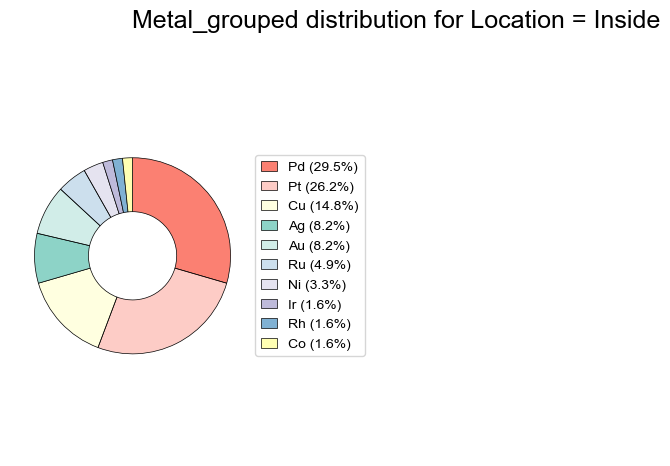

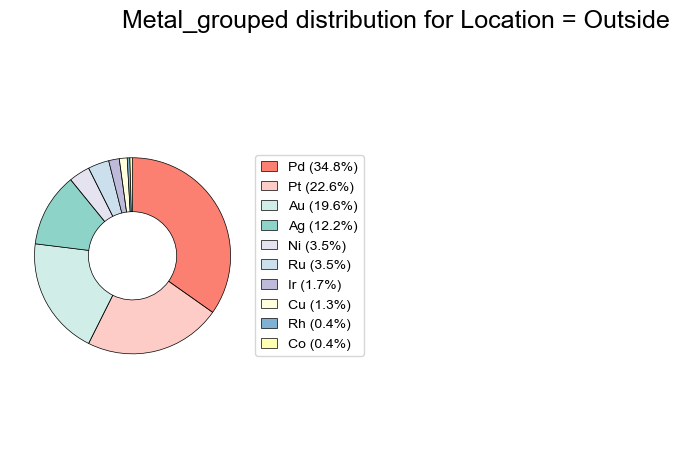

C:\Users\yibinjiang\AppData\Local\Temp\ipykernel_68220\3713299489.py:21: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



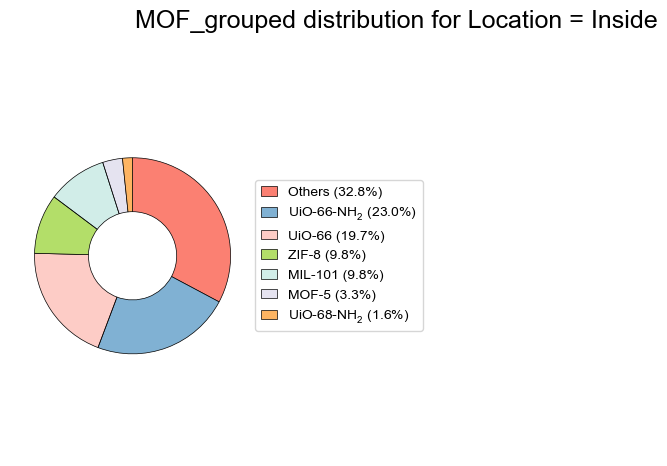

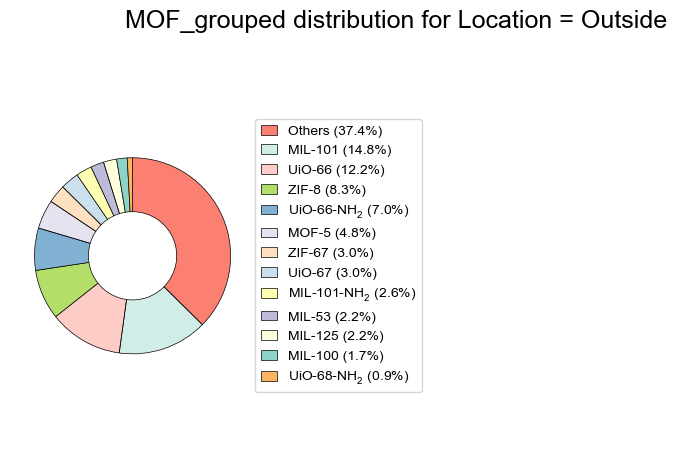

C:\Users\yibinjiang\AppData\Local\Temp\ipykernel_68220\3713299489.py:21: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



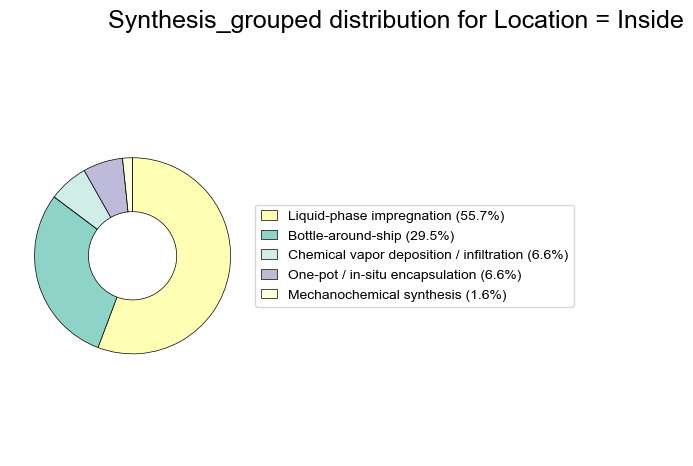

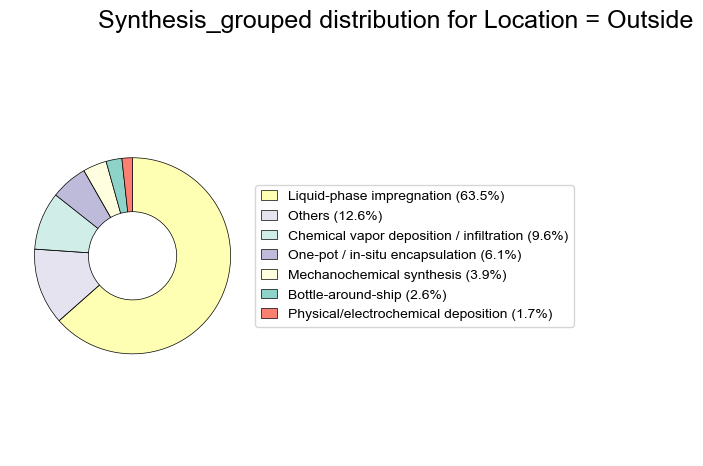

In [3]:
# ============================================================
# 4) MAIN: build union palette across ALL cases you have now
# ============================================================

# --- Put ALL your case DataFrames here ---
# If you only have df_clean right now, use: all_cases = [df_clean]
all_cases = [df_clean]  # <-- replace with [df_case1, df_case2, df_case3, ...]

for CATEGORY_COL in ["Metal_grouped", "MOF_grouped", "Synthesis_grouped"]:
    LOCATION_COL = "Location"
    # Normalize category column in ALL cases (recommended)
    for i in range(len(all_cases)):
        all_cases[i] = all_cases[i].copy()
        all_cases[i][CATEGORY_COL] = normalize_cat_series(all_cases[i][CATEGORY_COL])

    # Build master (union) categories across all cases
    df_all_cases = pd.concat(all_cases, ignore_index=True)
    master_cats = df_all_cases[CATEGORY_COL].dropna().unique().tolist()

    # Build global palette (stable mapping)
    cat_to_idx, cat_colors, cmap, norm, cats = build_category_palette(
        master_cats,
        max_colors=16,
        transparent_alpha=0.4,
    )

    # ============================================================
    # 5) PLOT: loop over locations in ONE chosen case (df_clean)
    #    (You can loop cases too if you want.)
    # ============================================================

    # Choose which case to plot now
    df_plot = df_clean.copy()
    df_plot[CATEGORY_COL] = normalize_cat_series(df_plot[CATEGORY_COL])

    for loc in sorted(df_plot[LOCATION_COL].dropna().unique()):
        df_sub = df_plot[df_plot[LOCATION_COL] == loc]

        fig = plot_one_location_pie_fixed(
            df_sub,
            category_col=CATEGORY_COL,
            cat_to_idx=cat_to_idx,
            cat_colors=cat_colors,
            font_family="Arial",
            legend_fs=36,
            figsize=(6.8, 5.2),
            legend_col_ratio=1.15,
            pie_width=0.55,
            edge_width=0.5,
            edge_color="black",
            min_fraction_to_show=0.0,  # set e.g. 0.01 to hide <1% entries
        )

        if fig is None:
            print(f"[skip] {loc}: no categories in global mapping.")
            continue
        plt.title(f"{CATEGORY_COL} distribution for Location = {loc}", fontsize=18, pad=20)

        plt.show()

        # bbox_inches="tight" is safe here because legend is inside its own axis,
        # and pie size won't be squeezed by tight_layout.
        fig.savefig(f"./{CATEGORY_COL}_{loc}.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
        plt.close(fig)


In [4]:
import pandas as pd
import numpy as np
import re

# =========================
# 0) Input
# =========================
file_path = "data_temp.xlsx"   # <- 改成你的文件名
sheet_name = "Sheet1"          # <- 改成你的Sheet

# =========================
# 1) Load
# =========================
df_raw = pd.read_excel(file_path, sheet_name=sheet_name)

# 你这个表的关键列名（如果你改过表头，这里也要改）
COL_METAL = "金属"
COL_NOTE  = "备注（混合金属）"
COL_SYN   = "合成方法"
COL_LOC   = "是否在外表面"
COL_REF   = "文献编号"
COL_ENTRY = "条目"

need_cols = [COL_METAL, COL_NOTE, COL_SYN, COL_LOC, COL_REF, COL_ENTRY]
missing = [c for c in need_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing columns in excel: {missing}\nFound: {list(df_raw.columns)}")

df = df_raw.copy()

# =========================
# 2) 文献编号归一化：12-1 / 12.0 / 12 -> 12
# =========================
def normalize_ref(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"\d+", s)  # 取第一个整数
    if not m:
        return s
    return int(m.group(0))

df["Ref_norm"] = df[COL_REF].apply(normalize_ref)

# =========================
# 3) 单金属 / 多金属判定
#   - 从 “金属” 和 “备注（混合金属）” 两列提取元素符号
# =========================
def extract_elements(s):
    if pd.isna(s):
        return []
    s = str(s)
    # 典型元素符号：Ag, Pd, Pt, Fe ...
    return re.findall(r"[A-Z][a-z]?", s)

def classify_metal(row):
    elems = set(extract_elements(row[COL_METAL]))
    all_elems = elems

    if len(all_elems) == 0:
        return np.nan, []
    if len(all_elems) == 1:
        return "Single-metal", sorted(all_elems)
    return "Multi-metal", sorted(all_elems)

df["Metal_class"], df["Metal_list"] = zip(*df.apply(classify_metal, axis=1))

# =========================
# 4) Location 归一化：是否在外表面 (0/1) -> Inside/Outside
#   - 你原始列里看起来 1=Outside, 0=Inside
# =========================
loc = df[COL_LOC].replace({
    0: "Inside", 1: "Outside",
    "0": "Inside", "1": "Outside",
    "No": "Inside", "Yes": "Outside",
    "no": "Inside", "yes": "Outside"
})
df["Location_norm"] = loc.where(loc.isin(["Inside", "Outside"]), np.nan)

# =========================
# 5) 合成方法归一化 + 分桶（复用你原来的逻辑）
# =========================
synthesis_mapping = {
    "SI": "Solution impregnation",
    "CVD": "Chemical vapor deposition",
    "SG": "Solid grinding",
    "solvent-free gas-phase infiltration": "Chemical vapor deposition",
    "DSM": "Double solvent method",
    "Electrodeposition": "Electrodeposition",
    "Incipient wetness impregnation": "Incipient wetness impregnation",
    "One-pot synthesis": "One-pot synthesis",
    "MOCVD": "Chemical vapor deposition",
    "Bottle-around-ship": "Bottle-around-ship",
    "immobilization": "Solution impregnation",
    "In-situ encapsulation": "One-pot synthesis",
    "wetness impregnation": "Incipient wetness impregnation",
}

df["Synthesis_norm"] = df[COL_SYN].replace(synthesis_mapping)

def bucket_synthesis_clear(s):
    if pd.isna(s):
        return np.nan
    s1 = str(s).strip()
    low = s1.lower()

    if re.search(r"(arc\s*plasma|plasma|sputter|pvd|physical\s*vapor|evaporation)", low):
        return "Physical / plasma deposition"
    if re.search(r"(chemical vapor|mocvd|cvd|gas[-\s]*phase|vapor infiltration|vapour infiltration)", low):
        return "Chemical vapor deposition / infiltration"
    if re.search(r"(electrodeposition|electrochemical)", low):
        return "Electrochemical deposition"
    if re.search(r"(solid grinding|grinding|mechanochem|ball milling|milling)", low):
        return "Mechanochemical synthesis"
    if re.search(r"(bottle[-\s]*around[-\s]*ship)", low):
        return "Bottle-around-ship"
    if re.search(r"(one[-\s]*pot|in[-\s]*situ|encapsulat)", low):
        return "One-pot / in-situ encapsulation"
    if re.search(r"(solution impregnation|incipient wetness|double solvent|wetness impregnation|impregnation)", low):
        return "Liquid-phase impregnation"
    return "Others"

df["Synthesis_grouped"] = df["Synthesis_norm"].apply(bucket_synthesis_clear)

# 合并两个小类（和你原来 sankey 逻辑一致）
df["Synthesis_grouped"] = df["Synthesis_grouped"].replace({
    "Physical / plasma deposition": "Physical/electrochemical deposition",
    "Electrochemical deposition": "Physical/electrochemical deposition"
})

# =========================
# 6) 任务 (1)：单金属/多金属：entries 与文献数
# =========================
overall = (
    df.groupby("Metal_class")
      .agg(
          entries=(COL_ENTRY, "count"),
          unique_papers=("Ref_norm", "nunique")
      )
      .reset_index()
)

overall["entries_per_paper"] = (overall["entries"] / overall["unique_papers"]).round(3)

# 全体汇总（All）
all_row = pd.DataFrame([{
    "Metal_class": "All",
    "entries": len(df),
    "entries_per_paper": round(len(df) / df["Ref_norm"].nunique(), 3)
}])
overall_full = pd.concat([overall, all_row], ignore_index=True)

# 统计：有多少篇文献同时出现在 single & multi
papers_single = set(df.loc[df["Metal_class"]=="Single-metal", "Ref_norm"].unique())
papers_multi  = set(df.loc[df["Metal_class"]=="Multi-metal",  "Ref_norm"].unique())
papers_both = len(papers_single & papers_multi)

print("\n=== (1) Single vs Multi: entries & unique papers ===")
print(overall_full.to_string(index=False))
print(f"\nPapers appearing in BOTH single-metal and multi-metal entries: {papers_both}")

# =========================
# 7) 任务 (2)：只看单金属 + (impregnation + inside) 子集内部，各方法比例
# =========================
single = df[df["Metal_class"] == "Single-metal"].copy()

# 你说的 “impregnation + inside”
subset = single[
    (single["Synthesis_grouped"] == "Liquid-phase impregnation") &
    (single["Location_norm"] == "Inside")
].copy()

# 子集内部：按 Synthesis_norm（SI/DSM/IWI...）统计比例
method_breakdown = (
    subset["Synthesis_norm"]
    .fillna(subset[COL_SYN])
    .value_counts()
    .rename_axis("Method")
    .reset_index(name="Count")
)
if len(method_breakdown) > 0:
    method_breakdown["Percent"] = (method_breakdown["Count"] / method_breakdown["Count"].sum() * 100).round(1)

print("\n=== (2) Single-metal + Liquid-phase impregnation + Inside: method breakdown ===")
print(f"Subset entries: {len(subset)}")
print(f"Subset unique papers: {subset['Ref_norm'].nunique()}")
print(method_breakdown.to_string(index=False) if len(method_breakdown) else "No rows in subset.")

# （可选）补充：单金属 inside 的来源：各大类贡献
inside_single = single[single["Location_norm"] == "Inside"].copy()
inside_by_group = (
    inside_single["Synthesis_grouped"]
    .value_counts()
    .rename_axis("Synthesis_grouped")
    .reset_index(name="Inside_entries")
)
if len(inside_by_group) > 0:
    inside_by_group["Inside_share_%"] = (inside_by_group["Inside_entries"] / inside_by_group["Inside_entries"].sum() * 100).round(1)

print("\n=== (Optional) Single-metal INSIDE entries: contribution by grouped synthesis ===")
print(f"Single-metal Inside entries: {len(inside_single)}")
print(f"Single-metal Inside papers : {inside_single['Ref_norm'].nunique()}")
print(inside_by_group.to_string(index=False) if len(inside_by_group) else "No inside rows.")

# =========================
# 8) 保存结果（可选）
# =========================
out_xlsx = "analysis_single_vs_multi_and_impreg_inside.xlsx"
with pd.ExcelWriter(out_xlsx) as w:
    overall_full.to_excel(w, index=False, sheet_name="single_vs_multi")
    method_breakdown.to_excel(w, index=False, sheet_name="impreg_inside_methods")
    inside_by_group.to_excel(w, index=False, sheet_name="inside_by_group")
    subset.to_excel(w, index=False, sheet_name="subset_rows")

print(f"\nSaved results to: {out_xlsx}")



=== (1) Single vs Multi: entries & unique papers ===
 Metal_class  entries  unique_papers  entries_per_paper
 Multi-metal       62           45.0              1.378
Single-metal      291          181.0              1.608
         All      353            NaN              1.634

Papers appearing in BOTH single-metal and multi-metal entries: 10

=== (2) Single-metal + Liquid-phase impregnation + Inside: method breakdown ===
Subset entries: 34
Subset unique papers: 27
               Method  Count  Percent
Solution impregnation     19     55.9
Double solvent method     15     44.1

=== (Optional) Single-metal INSIDE entries: contribution by grouped synthesis ===
Single-metal Inside entries: 61
Single-metal Inside papers : 49
                       Synthesis_grouped  Inside_entries  Inside_share_%
               Liquid-phase impregnation              34            55.7
                      Bottle-around-ship              18            29.5
Chemical vapor deposition / infiltration          

In [ ]:
# unique_papers not trustable above

In [5]:
df.loc[df["Metal_class"]=="Single-metal", "Ref_norm"].unique()

array([  3,   4,   9,  15,  32,  69, 108, 109, 110, 131, 144, 183, 184,
       164, 187, 195, 203, 206, 209, 211, 212, 213, 231, 235, 237, 244,
         6,  12,  16,  18,  21,  23,  29,  33,  43,  58,  78,  79,  80,
        93, 113, 125, 141, 142, 143, 118,   1, 151, 150, 157, 139, 185,
       194, 205, 214, 219, 233, 240,  11,  13,  19,  20,  25,  26,  27,
        28,  31,  35,  36,  37,  40,  49,  50,  51,  52,  53,  54,  55,
        61,  62,  63,  72,  74,  81,  82,  83,  84,  85,  90,  91,  96,
        97,  98,  99, 107, 122, 123, 124, 134, 136, 145, 149,  73, 177,
       179, 166,  77, 156, 168, 189, 192, 196, 197, 198, 200, 210, 217,
       232, 239, 175, 241, 242,  44, 222,  14,  42,  60,  64,  65,  75,
        87,  89, 100, 104, 115, 116, 117, 128, 133, 138, 146, 147, 153,
       101, 180, 159, 186, 188, 130, 207, 208, 215, 216, 226, 234, 236,
       132, 155, 126, 243,  66,  88,  10, 193, 204, 218, 221, 224, 225,
        24,  45,  48,  59, 201, 220,   7,  41, 102, 119, 148, 17

In [ ]:
df.loc[df["Metal_class"]=="Single-metal", "Ref_norm"].unique()

In [6]:
df.loc[df["Metal_class"]=="Multi-metal", "Ref_norm"].unique()

array([ 32,  92, 120, 164,  77, 161, 191, 228,  34,  57, 105, 178, 163,
       167, 188, 106, 199, 202, 205, 223, 229,  19,  47,  71, 140, 154,
       179, 180, 158, 160,  67, 181, 169, 137, 208, 238, 227, 103, 129,
       182, 171, 230, 190, 173, 126])

In [7]:
sum(df_clean["Location"]=="Inside")

61

In [8]:
df_clean["Metal_grouped"]

0      Ag
1      Ag
2      Ag
3      Ag
4      Ag
       ..
286    Ru
287    Ru
288    Ru
289    Ru
290    Ru
Name: Metal_grouped, Length: 291, dtype: object

In [9]:
df.loc[df["Metal_class"] == "Multi-metal"]["金属"].iloc[0]

'AgAu'

In [10]:
sum(df_clean["Location"] == "Outside")

230

In [11]:
df_clean

,Metal_grouped,MOF_grouped,Synthesis_grouped,Location
0,Ag,Others,Liquid-phase impregnation,Outside
1,Ag,Others,Liquid-phase impregnation,Outside
2,Ag,Others,Liquid-phase impregnation,Outside
3,Ag,Others,Chemical vapor deposition / infiltration,Outside
4,Ag,Others,Chemical vapor deposition / infiltration,Outside
...,...,...,...,...
286,Ru,UiO-66,Liquid-phase impregnation,Outside
287,Ru,MIL-101,Liquid-phase impregnation,Outside
288,Ru,ZIF-8,Mechanochemical synthesis,Outside
289,Ru,ZIF-8,Physical/electrochemical deposition,Outside


In [ ]:
from pathlib import Path
import re
import pandas as pd
import shutil

# --- inputs ---
pdf_dir = Path(r"C:\Users\yibinjiang\Desktop\综述\MNPs—MOF文献 - 标号")

# Build an ID set from your dataframe column (works for int + strings like '134-1')
id_set = set(df["文献编号"].astype(str).str.strip())

# Match leading ID: "1-....pdf", "81-....pdf", "134-1-....pdf", "118-2-....pdf"
pat = re.compile(r"^\s*(\d+(?:-\d+)?)")

rows = []
found_ids = set()

for p in pdf_dir.rglob("*.pdf"):  # use .glob("*.pdf") if you only want top-level
    stem = p.stem  # filename without ".pdf"
    m = pat.match(stem)
    file_id = m.group(1) if m else None
    in_list = (file_id in id_set) if file_id else False

    if in_list:
        found_ids.add(file_id)

    rows.append({
        "file": str(p),
        "file_id": file_id,
        "in_list": in_list,
        "filename": p.name
    })

res = pd.DataFrame(rows)

matched = res[res["in_list"]].copy()
unmatched_files = res[~res["in_list"]].copy()

# IDs that are in df list but have no corresponding PDF filename
def sort_key(x: str):
    parts = x.split("-")
    a = int(parts[0])
    b = int(parts[1]) if len(parts) > 1 else -1
    return (a, b)

missing_ids = sorted(id_set - found_ids, key=sort_key)

print(f"Total PDFs scanned: {len(res)}")
print(f"Matched PDFs: {len(matched)}")
print(f"Unmatched PDFs (ID not in list or no ID parsed): {len(unmatched_files)}")
print(f"Missing IDs (in list but no PDF found): {len(missing_ids)}")

# Save reports
matched_csv = pdf_dir / "matched_pdfs.csv"
unmatched_csv = pdf_dir / "unmatched_pdfs.csv"
missing_csv = pdf_dir / "missing_ids.csv"

matched.to_csv(matched_csv, index=False, encoding="utf-8-sig")
unmatched_files.to_csv(unmatched_csv, index=False, encoding="utf-8-sig")
pd.DataFrame({"missing_id": missing_ids}).to_csv(missing_csv, index=False, encoding="utf-8-sig")

print("Wrote:", matched_csv, unmatched_csv, missing_csv)

# --- optional: copy matched PDFs to a new folder ---
out_dir = pdf_dir / "_matched"
out_dir.mkdir(exist_ok=True)

for src in matched["file"]:
    src = Path(src)
    shutil.copy2(src, out_dir / src.name)

print("Copied matched PDFs to:", out_dir)

In [ ]:
from pathlib import Path
import pandas as pd

pdf_dir = Path(r"C:\Users\yibinjiang\Desktop\综述\ms")
ids = df["文献编号"].astype(str).str.strip().unique().tolist()
pdfs = list(pdf_dir.rglob("*.pdf"))

hit = {}
miss_ids = []

for fid in ids:
    prefix = f"{fid}-"
    matches = [p for p in pdfs if p.name.startswith(prefix)]
    if matches:
        hit[fid] = matches
    else:
        miss_ids.append(fid)

# 导出
rows = [{"file_id": fid, "pdf": str(p)} for fid, ps in hit.items() for p in ps]
pd.DataFrame(rows).to_csv(pdf_dir / "matched_by_prefix.csv", index=False, encoding="utf-8-sig")
pd.DataFrame({"missing_id": miss_ids}).to_csv(pdf_dir / "missing_ids.csv", index=False, encoding="utf-8-sig")

In [ ]:
import shutil

out_dir = pdf_dir / "_matched_pdfs"
out_dir.mkdir(exist_ok=True)

def safe_copy(src: Path, dst_dir: Path) -> Path:
    """Copy src into dst_dir; if name exists, append _2/_3..."""
    dst = dst_dir / src.name
    if not dst.exists():
        shutil.copy2(src, dst)
        return dst

    stem, suffix = src.stem, src.suffix
    k = 2
    while True:
        cand = dst_dir / f"{stem}_{k}{suffix}"
        if not cand.exists():
            shutil.copy2(src, cand)
            return cand
        k += 1

copied = []
for fid, paths in hit.items():
    for p in paths:
        new_path = safe_copy(Path(p), out_dir)
        copied.append({"file_id": fid, "src": str(p), "dst": str(new_path)})

pd.DataFrame(copied).to_csv(out_dir / "copied_log.csv", index=False, encoding="utf-8-sig")
print(f"Copied {len(copied)} PDFs to: {out_dir}")

In [ ]:
df["Metal_class"]

In [ ]:
df.loc[df["Metal_class"]=="Single-metal", "Ref_norm"].unique().shape

In [12]:
df.loc[df["Metal_class"]=="Single-metal", "文献编号"].unique().shape

(185,)

In [13]:
df.loc[df["Metal_class"]=="Single-metal", "文献编号"].unique()

array([3, 4, 9, 15, 32, 69, 108, 109, 110, 131, 144, 183, 184, 164, 187,
       195, 203, 206, 209, 211, 212, 213, 231, 235, 237, 244, 6, 12, 16,
       18, 21, 23, 29, 33, 43, 58, 78, 79, 80, 93, 113, 125, 141, 142,
       143, 118, 1, 151, 150, 157, 139, 185, 194, 205, 214, 219, 233, 240,
       11, 13, 19, 20, 25, 26, 27, 28, 31, 35, 36, 37, 40, 49, 50, 51, 52,
       53, 54, 55, 61, 62, 63, 72, 74, 81, 82, 83, 84, 85, 90, 91, 96, 97,
       98, 99, 107, 122, 123, 124, '134-1', 136, 145, 149, 73, 177, 179,
       166, 77, 156, 168, 189, 192, 196, 197, 198, 200, 210, 217, 232,
       239, 175, 241, 242, 44, '118-1', 222, 14, 42, 60, 64, 65, 75, 87,
       '89-1', 100, 104, 115, 116, 117, 128, 133, 134, 138, 146, 147, 153,
       101, 180, 159, 186, 188, 130, 207, 208, 215, 216, 226, 234, 236,
       132, 155, 126, 243, 66, 88, 10, 193, 204, 218, 221, 224, 225,
       '118-2', 24, 45, 48, 59, 201, 220, 7, 41, 89, 102, 119, 148, 174],
      dtype=object)